# Mixture Gaussians
Vamos aplicar o modelo probabilístico **Mixture Gaussians** para achar clusters
$$
    \ln p(X|\mu, \Sigma, \pi) = \sum_{n=1}^N \ln \{ \sum_{k=1}^K \pi_k \mathcal{N}(x_n|\mu_k, \Sigma_k) \}
$$

## Configuração
Importando bibliotecas necessárias e configuração para utilização de placa de vídeo (se possível)

In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import os
from torch.distributions import MultivariateNormal
import sys
from pathlib import Path

root = Path().resolve().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Dados
Importando os dados e fazendo visualização inicial. Dados disponíveis [aqui](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv)

In [2]:
data = pd.read_csv(os.path.join(root, 'data', 'geyser.csv'))

In [3]:
data.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


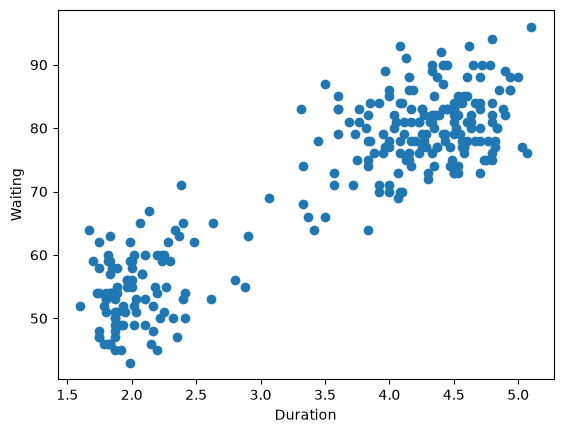

In [4]:
plt.plot(data['duration'], data['waiting'], 'o')
plt.xlabel('Duration')
plt.ylabel('Waiting')
plt.show()

In [5]:
X = torch.tensor(data.drop(columns=['kind']).values, device=device, dtype=torch.float32)

## Modelo

In [6]:
def init_params(k, d, device, X):
    N = X.shape[0]
    indices = torch.randperm(N)[:k]
    mu = X[indices].clone()
    covariances = torch.eye(d, device=device).unsqueeze(0).repeat(k, 1, 1)
    pi = torch.ones(k, device=device) / k
    return mu, covariances, pi


def e_step(X, mu, covariances, pi):
    log_probs = []
    for k in range(mu.shape[0]):
        dist = MultivariateNormal(loc=mu[k], covariance_matrix=covariances[k])
        log_probs.append(dist.log_prob(X))

    log_probs = torch.stack(log_probs, dim=1)
    log_pi = torch.log(pi)
    log_weighted = log_pi + log_probs
    log_denom = torch.logsumexp(log_weighted, dim=1, keepdim=True)
    log_r = log_weighted - log_denom
    r = log_r.exp()
    return r


def m_step(X, r, d, device):
    Ns = r.sum(dim=0)
    mu = (r.T @ X) / Ns.unsqueeze(1)

    eps = 1e-6
    K = mu.shape[0]
    covariances = torch.zeros(K, d, d, device=device)

    for k in range(K):
        diff = X - mu[k]
        weighted = r[:, k].unsqueeze(1) * diff
        covariances[k] = (weighted.T @ diff) / Ns[k] + eps * torch.eye(d, device=device)

    pi = Ns / X.shape[0]
    return mu, covariances, pi


def log_likelihood(X, mu, covariances, pi):
    log_probs = []
    for k in range(mu.shape[0]):
        dist = MultivariateNormal(loc=mu[k], covariance_matrix=covariances[k])
        log_probs.append(dist.log_prob(X))

    log_probs = torch.stack(log_probs, dim=1)
    log_pi = torch.log(pi)
    log_weighted = log_pi + log_probs
    log_px = torch.logsumexp(log_weighted, dim=1)
    return log_px.sum()


def fit_gmm(X, k, convergence_criterium, max_iterations=1000, device=torch.device('cpu')):
    mu, covariances, pi = init_params(k, X.shape[1], device, X)

    previous = [mu.clone(), covariances.clone(), pi.clone()]
    criteriums = [False, False, False]

    for _ in range(max_iterations):
        r = e_step(X, mu, covariances, pi)
        mu, covariances, pi = m_step(X, r, X.shape[1], device)

        criteriums[0] = convergence_criterium(mu, previous[0])
        criteriums[1] = convergence_criterium(covariances, previous[1])
        criteriums[2] = convergence_criterium(pi, previous[2])

        if sum(criteriums) == 3:
            break

        previous = [mu.clone(), covariances.clone(), pi.clone()]

    ll = log_likelihood(X, mu, covariances, pi)
    return {
        'k': k,
        'mu': mu,
        'covariances': covariances,
        'pi': pi,
        'log_likelihood': ll
    }

## Treinamento

In [7]:
ks = [1, 2, 3, 4, 5]
results = []

def convergence_criterium(old_params, new_params):
    return torch.norm(new_params - old_params) < 1e-4

for k in ks:
    result = fit_gmm(X, k, convergence_criterium, device=device)
    results.append(result)

In [8]:
def BIC(result, X):
    """
    Bayesian Information Criterion for model selection.

    Args:
        result (dict): Fitted GMM result from fit_gmm.
        X (torch.Tensor): The data used to fit the model.

    Returns:
        float: The BIC score for the model.
    """
    N, D = X.shape
    K = result['k']
    log_likelihood = result['log_likelihood'].item()
    num_params = K * D + K - 1 + K * (D * (D + 1) // 2)
    bic_score = -2 * log_likelihood + num_params * torch.log(torch.tensor(N)).item()
    return bic_score

In [9]:
bic_scores = [BIC(r, X) for r in results]
best_idx = bic_scores.index(min(bic_scores))
best_k = ks[best_idx]
print(f"Best number of components according to BIC: {best_k}")

Best number of components according to BIC: 2


In [10]:
best_result = results[best_idx]
print(f"Means:\n{best_result['mu']}")
print(f"Covariances:\n{best_result['covariances']}")
print(f"Mixing Coefficients:\n{best_result['pi']}")

Means:
tensor([[ 4.2897, 79.9681],
        [ 2.0364, 54.4785]], device='cuda:0')
Covariances:
tensor([[[ 0.1700,  0.9406],
         [ 0.9406, 36.0462]],

        [[ 0.0692,  0.4352],
         [ 0.4352, 33.6973]]], device='cuda:0')
Mixing Coefficients:
tensor([0.6441, 0.3559], device='cuda:0')


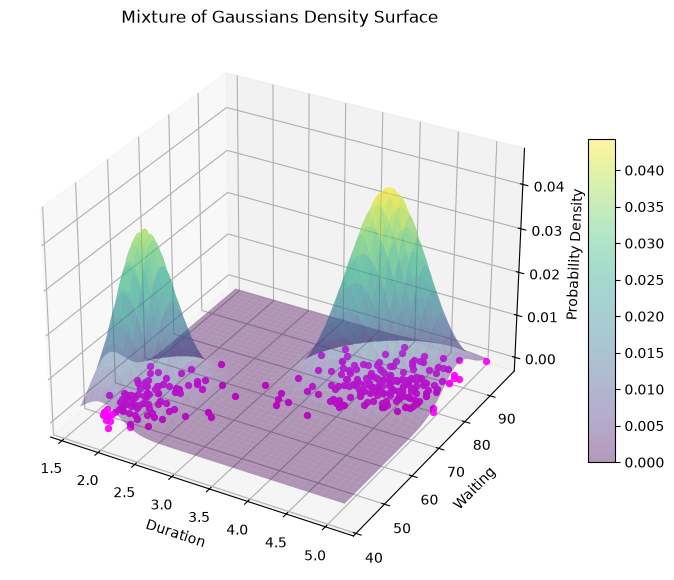

In [11]:
# 3D surface of the mixture density over the feature space
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

mu = best_result['mu'].detach().cpu()
covs = best_result['covariances'].detach().cpu()
pis = best_result['pi'].detach().cpu()

X_cpu = X.detach().cpu().numpy()
x_min, x_max = X_cpu[:, 0].min(), X_cpu[:, 0].max()
y_min, y_max = X_cpu[:, 1].min(), X_cpu[:, 1].max()
gx = np.linspace(x_min, x_max, 120)
gy = np.linspace(y_min, y_max, 120)
XX, YY = np.meshgrid(gx, gy)
grid = np.column_stack([XX.ravel(), YY.ravel()])

grid_t = torch.tensor(grid, dtype=torch.float32)
K = best_result['k']
D = grid_t.shape[1]
norm_const = (2 * np.pi) ** (D / 2)
dens = torch.zeros(grid_t.shape[0], dtype=torch.float32)

for k in range(K):
    diff = grid_t - mu[k]
    cov = covs[k]
    inv_cov = torch.linalg.inv(cov)
    det_cov = torch.linalg.det(cov)
    exponent = -0.5 * torch.sum((diff @ inv_cov) * diff, dim=1)
    comp = torch.exp(exponent) / (norm_const * torch.sqrt(det_cov))
    dens += pis[k] * comp

ZZ = dens.reshape(XX.shape).numpy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XX, YY, ZZ, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.4)

z0 = np.zeros_like(X_cpu[:, 0])
ax.scatter(X_cpu[:, 0], X_cpu[:, 1], z0, color='#ff00ff', s=18, alpha=0.9, depthshade=False)

ax.set_xlabel('Duration')
ax.set_ylabel('Waiting')
ax.set_zlabel('Probability Density')
ax.set_title('Mixture of Gaussians Density Surface')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.show()